In [1]:
!pip install torch torchvision -q

## Verify GPU

In [2]:
import torch

print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: Tesla T4


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


## Import Libraries

In [4]:
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import time
import os

## Settings

In [5]:
# =========================================================
# TRAINING CONFIGURATION
# =========================================================

ROUNDS = 20
CLIENTS_PER_ROUND = 5
LOCAL_EPOCHS = 1
LR=0.005
MU=0.01
ALPHA=0.1

## Mount Google Drive

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
project_path = "/content/drive/MyDrive/FL_Project"

os.makedirs(project_path, exist_ok=True)

dataset_path = os.path.join(project_path, "datasets")

os.makedirs(dataset_path, exist_ok=True)

##Download CIFAR-10 Dataset

(Note that we have not used data augmentation (padding and horizontal flip))

In [8]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_dataset = datasets.CIFAR10(
    root=dataset_path,
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root=dataset_path,
    train=False,
    download=True,
    transform=transform
)

##Create Test Loader

In [9]:
test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    drop_last=True,
    pin_memory=torch.cuda.is_available()
)

## Create IID Client Dataset:

In [10]:
# =========================================================
# HIGHLY NON-IID CLIENT DATASET + LOADERS
# =========================================================

num_clients = 10
alpha = ALPHA
batch_size = 64

labels = np.array(train_dataset.targets)

client_indices = [[] for _ in range(num_clients)]

# ---------------------------------------------------------
# DIRICHLET NON-IID SPLIT
# ---------------------------------------------------------

for class_id in range(10):

    class_indices = np.where(labels == class_id)[0]

    np.random.shuffle(class_indices)

    proportions = np.random.dirichlet(
        np.repeat(alpha, num_clients)
    )

    proportions = (
        np.cumsum(proportions) * len(class_indices)
    ).astype(int)[:-1]

    split_class_indices = np.split(
        class_indices,
        proportions
    )

    for client_id in range(num_clients):

        client_indices[client_id].extend(
            split_class_indices[client_id]
        )

# ---------------------------------------------------------
# CREATE CLIENT LOADERS
# ---------------------------------------------------------

client_loaders = []

for client_id in range(num_clients):

    np.random.shuffle(client_indices[client_id])

    subset = Subset(
        train_dataset,
        client_indices[client_id]
    )

    loader = DataLoader(
        subset,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True
    )

    client_loaders.append(loader)

print("Highly Non-IID Client Loaders Created!")

Highly Non-IID Client Loaders Created!


## Verify Client Data Sizes

In [11]:
for i, loader in enumerate(client_loaders):
    print(f"Client {i}: {len(loader.dataset)} samples")

Client 0: 4382 samples
Client 1: 2473 samples
Client 2: 9373 samples
Client 3: 5434 samples
Client 4: 2087 samples
Client 5: 3926 samples
Client 6: 4586 samples
Client 7: 9501 samples
Client 8: 1470 samples
Client 9: 6768 samples


In [12]:
# =========================================================
# PRINT CLIENT DATA DISTRIBUTION
# =========================================================

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

for client_id in range(num_clients):

    print(f"\n{'='*50}")
    print(f"CLIENT {client_id}")
    print(f"{'='*50}")

    client_labels = labels[client_indices[client_id]]

    class_counts = np.bincount(
        client_labels,
        minlength=10
    )

    for class_id in range(10):

        print(
            f"{class_names[class_id]:12s}: "
            f"{class_counts[class_id]}"
        )


CLIENT 0
airplane    : 24
automobile  : 0
bird        : 305
cat         : 0
deer        : 174
dog         : 0
frog        : 2377
horse       : 1
ship        : 0
truck       : 1501

CLIENT 1
airplane    : 36
automobile  : 0
bird        : 0
cat         : 39
deer        : 0
dog         : 4
frog        : 1904
horse       : 4
ship        : 0
truck       : 486

CLIENT 2
airplane    : 0
automobile  : 0
bird        : 2377
cat         : 3838
deer        : 0
dog         : 2722
frog        : 1
horse       : 91
ship        : 344
truck       : 0

CLIENT 3
airplane    : 1604
automobile  : 167
bird        : 2
cat         : 0
deer        : 25
dog         : 95
frog        : 1
horse       : 0
ship        : 3083
truck       : 457

CLIENT 4
airplane    : 0
automobile  : 976
bird        : 684
cat         : 0
deer        : 9
dog         : 246
frog        : 0
horse       : 1
ship        : 171
truck       : 0

CLIENT 5
airplane    : 30
automobile  : 0
bird        : 0
cat         : 0
deer        : 184
dog    

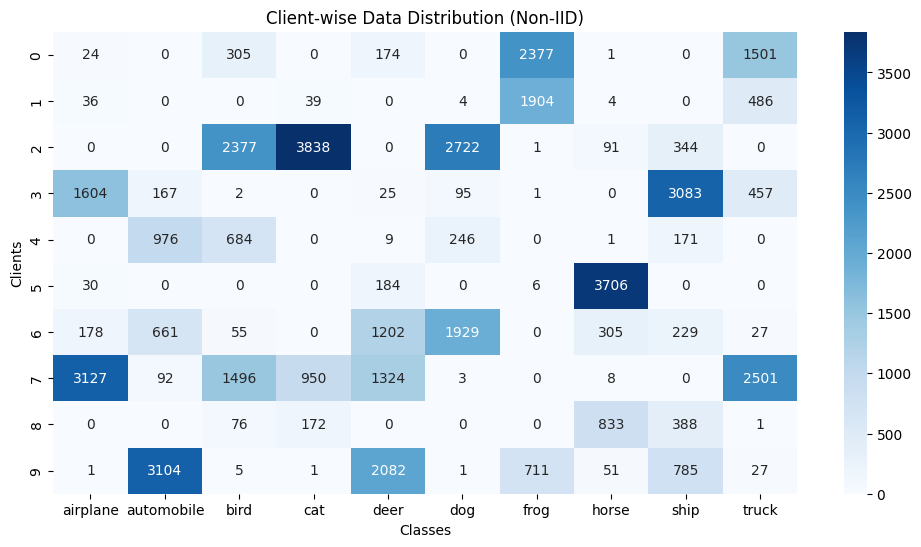

In [13]:
# =========================================================
# CLIENT-WISE CLASS DISTRIBUTION
# =========================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

distribution = []

for client_id in range(num_clients):

    client_labels = labels[client_indices[client_id]]

    class_counts = np.bincount(
        client_labels,
        minlength=10
    )

    distribution.append(class_counts)

distribution = np.array(distribution)

df = pd.DataFrame(
    distribution,
    columns=[
        "airplane",
        "automobile",
        "bird",
        "cat",
        "deer",
        "dog",
        "frog",
        "horse",
        "ship",
        "truck"
    ]
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    df,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Classes")
plt.ylabel("Clients")
plt.title("Client-wise Data Distribution (Non-IID)")

plt.show()

## Define CNN Model

In [14]:
class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.relu(self.conv1(x))
        x = self.pool(x)

        x = self.relu(self.conv2(x))
        x = self.pool(x)

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x

## Scaffold control variates

In [15]:
# =========================================================
# SCAFFOLD CONTROL VARIATES
# =========================================================

server_control = {}

temp_model = CNN().to(device)

for key, value in temp_model.state_dict().items():

    server_control[key] = torch.zeros_like(value)

client_controls = []

for _ in range(num_clients):

    local_control = {}

    for key, value in temp_model.state_dict().items():

        local_control[key] = torch.zeros_like(value)

    client_controls.append(local_control)

print("SCAFFOLD control variates initialized!")

SCAFFOLD control variates initialized!


## Define Global Model

In [16]:
global_model = CNN().to(device)

print(global_model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
  (relu): ReLU()
)


## Define Evaluation Function

In [17]:
def evaluate(model, test_loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    return accuracy

In [18]:
# =========================================================
# GRADIENT NORM TRACKING
# =========================================================

gradient_norms = []

def get_gradient_norm(model):

    total_norm = 0.0

    for p in model.parameters():

        if p.grad is not None:

            param_norm = p.grad.data.norm(2)

            total_norm += param_norm.item() ** 2

    return total_norm ** 0.5

## Define Local Training Function (with Gradient Clipping)

In [19]:
def local_train(
    model,
    global_model,
    loader,
    epochs=1,
    lr=LR,
    clip_grad=True,
    max_norm=1.0,
    fedprox=False,
    mu=MU
):

    model.train()

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=0.9
    )

    epoch_loss = 0

    global_weights = copy.deepcopy(global_model.state_dict())

    for epoch in range(epochs):

        batch_losses = []

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            # =================================================
            # FEDPROX PROXIMAL TERM
            # =================================================

            if fedprox:

                proximal_term = 0.0

                for param, global_param in zip(
                    model.parameters(),
                    global_model.parameters()
                ):

                    proximal_term += torch.norm(
                        param - global_param
                    ) ** 2

                loss += (mu / 2) * proximal_term

            # =================================================
            # BACKPROPAGATION
            # =================================================

            loss.backward()

            # =================================================
            # RECORD GRADIENT NORM
            # =================================================

            grad_norm = get_gradient_norm(model)

            gradient_norms.append(grad_norm)


            # =================================================
            # GRADIENT CLIPPING
            # =================================================

            if clip_grad:

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=max_norm
                )

            optimizer.step()

            batch_losses.append(loss.item())

        epoch_loss += sum(batch_losses) / len(batch_losses)

    avg_loss = epoch_loss / epochs

    return model.state_dict(), avg_loss

# =========================================================
# 11. FEDAVG AGGREGATION
# =========================================================

def fedavg_aggregate(global_model, client_weights):

    global_dict = global_model.state_dict()

    for key in global_dict.keys():

        global_dict[key] = torch.stack([
            client_weights[i][key].float()
            for i in range(len(client_weights))
        ], 0).mean(0)

    global_model.load_state_dict(global_dict)

    return global_model

In [20]:
# =========================================================
# SCAFFOLD LOCAL TRAINING
# =========================================================

def scaffold_local_train(
    model,
    global_model,
    loader,
    client_control,
    server_control,
    epochs=1,
    lr=LR,
    clip_grad=True,
    max_norm=1.0
):

    model.train()

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=0.9
    )

    epoch_loss = 0

    global_weights = copy.deepcopy(
        global_model.state_dict()
    )

    for epoch in range(epochs):

        batch_losses = []

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            grad_norm = get_gradient_norm(model)

            gradient_norms.append(grad_norm)

            # =================================================
            # SCAFFOLD CORRECTION
            # =================================================

            with torch.no_grad():

                for name, param in model.named_parameters():

                    correction = (
                        server_control[name]
                        - client_control[name]
                    )

                    param.grad += correction.to(device)

            # =================================================
            # GRADIENT CLIPPING
            # =================================================

            if clip_grad:

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=max_norm
                )

            optimizer.step()

            batch_losses.append(loss.item())

        epoch_loss += sum(batch_losses) / len(batch_losses)

    avg_loss = epoch_loss / epochs

    # =====================================================
    # UPDATE CLIENT CONTROL VARIATE
    # =====================================================

    new_client_control = {}

    local_weights = model.state_dict()

    for key in client_control.keys():

        new_client_control[key] = (
            client_control[key]
            - server_control[key]
            + (global_weights[key] - local_weights[key]) / (epochs * lr)
        )

    return (
        model.state_dict(),
        avg_loss,
        new_client_control
    )

## Define FedAvg Aggregation

In [21]:
def fedavg_aggregate(global_model, client_weights):

    global_dict = global_model.state_dict()

    for key in global_dict.keys():

        global_dict[key] = torch.stack([
            client_weights[i][key].float()
            for i in range(len(client_weights))
        ], 0).mean(0)

    global_model.load_state_dict(global_dict)

    return global_model

## 12. TRIMMED MEAN AGGREGATION (5%):

In [22]:
def trimmed_mean_aggregate(
    global_model,
    client_weights,
    trim_ratio=0.05
):

    global_dict = global_model.state_dict()

    num_clients = len(client_weights)

    trim_k = max(1, int(num_clients * trim_ratio))

    for key in global_dict.keys():

        stacked = torch.stack([
            client_weights[i][key].float()
            for i in range(num_clients)
        ], 0)

        sorted_vals, _ = torch.sort(stacked, dim=0)

        trimmed = sorted_vals[
            trim_k : num_clients - trim_k
        ]

        global_dict[key] = trimmed.mean(0)

    global_model.load_state_dict(global_dict)

    return global_model

## Generic Federated Training Loop

In [23]:
def federated_train(
    method_name="FedAvg",
    rounds=ROUNDS,
    clients_per_round=2,
    local_epochs=1,
    clip_grad=True,
    fedprox=False,
    trimmed_mean=False,
    scaffold=False,
    max_norm=1.0,
):

    print("\n" + "="*70)
    print(f"METHOD: {method_name}")
    print("="*70)

    global_model = CNN().to(device)

    global_accuracies = []

    round_losses = []

    best_accuracy = 0

    best_model_weights = None

    previous_accuracy = 0

    for round_num in range(rounds):

        start_time = time.time()

        print("\n" + "="*60)
        print(f"Round {round_num+1}/{rounds}")
        print("="*60)

        # =================================================
        # CLIENT SELECTION
        # =================================================

        selected_clients = np.random.choice(
            range(num_clients),
            clients_per_round,
            replace=False
        )

        print(f"\nSelected Clients: {selected_clients}\n")

        client_weights = []

        client_losses = []

        # =================================================
        # LOCAL TRAINING
        # =================================================

        for client_id in selected_clients:

          local_model = copy.deepcopy(global_model)

          # =====================================================
          # SCAFFOLD TRAINING
          # =====================================================

          if scaffold:

              weights, loss, updated_control = scaffold_local_train(
                  model=local_model,
                  global_model=global_model,
                  loader=client_loaders[client_id],
                  client_control=client_controls[client_id],
                  server_control=server_control,
                  epochs=local_epochs,
                  clip_grad=clip_grad
              )

              client_controls[client_id] = updated_control

          # =====================================================
          # NORMAL METHODS
          # =====================================================

          else:

              weights, loss = local_train(
              model=local_model,
              global_model=global_model,
              loader=client_loaders[client_id],
              epochs=local_epochs,
              clip_grad=clip_grad,
              max_norm=max_norm,
              fedprox=fedprox
          )

          client_weights.append(weights)

          client_losses.append(loss)

          print(f"Client {client_id} Loss: {loss:.4f}")

        # =================================================
        # AGGREGATION
        # =================================================

        if trimmed_mean:

            global_model = trimmed_mean_aggregate(
                global_model,
                client_weights,
                trim_ratio=0.05
            )

        else:

            global_model = fedavg_aggregate(
                global_model,
                client_weights
            )

        # =================================================
        # EVALUATE GLOBAL MODEL
        # =================================================

        accuracy = evaluate(global_model, test_loader)

        global_accuracies.append(accuracy)

        avg_client_loss = sum(client_losses) / len(client_losses)

        round_losses.append(avg_client_loss)

        accuracy_change = accuracy - previous_accuracy

        if accuracy > best_accuracy:

            best_accuracy = accuracy

            best_model_weights = copy.deepcopy(
                global_model.state_dict()
            )

        round_duration = time.time() - start_time

        # =================================================
        # ROUND SUMMARY
        # =================================================

        print("\n" + "-"*20 + " ROUND SUMMARY " + "-"*20)

        print(f"\nAverage Client Loss : {avg_client_loss:.4f}")

        print(f"Global Accuracy     : {accuracy:.2f}%")

        print(f"Accuracy Change     : {accuracy_change:+.2f}%")

        print(f"Best Accuracy       : {best_accuracy:.2f}%")

        print(f"Round Duration      : {round_duration:.2f} sec")

        previous_accuracy = accuracy

    # =====================================================
    # LOAD BEST MODEL
    # =====================================================

    global_model.load_state_dict(best_model_weights)

    # =====================================================
    # SAVE MODEL
    # =====================================================

    save_path = os.path.join(
        project_path,
        f"{method_name}_best_model.pth"
    )

    torch.save(best_model_weights, save_path)

    print("\nTraining Complete!")

    print(f"Best Accuracy: {best_accuracy:.2f}%")

    return global_accuracies, round_losses


## CALIBRATION RUN


In [24]:
gradient_norms = []

print("Running Calibration...")

_ = federated_train(
    method_name="Calibration",
    rounds=3,
    clients_per_round=CLIENTS_PER_ROUND,
    local_epochs=LOCAL_EPOCHS,
    clip_grad=True
)

import numpy as np

OPTIMAL_CLIP_NORM = np.percentile(
    gradient_norms,
    95
)

print("\n" + "="*60)
print(f"OPTIMAL CLIP NORM = {OPTIMAL_CLIP_NORM:.4f}")
print("="*60)

Running Calibration...

METHOD: Calibration

Round 1/3

Selected Clients: [0 2 3 6 1]

Client 0 Loss: 1.2244
Client 2 Loss: 1.3337
Client 3 Loss: 1.3118
Client 6 Loss: 1.6948
Client 1 Loss: 1.2988

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.3727
Global Accuracy     : 15.49%
Accuracy Change     : +15.49%
Best Accuracy       : 15.49%
Round Duration      : 12.88 sec

Round 2/3

Selected Clients: [9 4 0 8 7]

Client 9 Loss: 1.2665
Client 4 Loss: 1.5674
Client 0 Loss: 0.9449
Client 8 Loss: 1.9335
Client 7 Loss: 1.3779

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.4180
Global Accuracy     : 17.46%
Accuracy Change     : +1.96%
Best Accuracy       : 17.46%
Round Duration      : 9.80 sec

Round 3/3

Selected Clients: [2 8 1 3 5]

Client 2 Loss: 1.2609
Client 8 Loss: 1.6454
Client 1 Loss: 0.8967
Client 3 Loss: 1.1670
Client 5 Loss: 0.6075

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.115

## Plotting the histogram

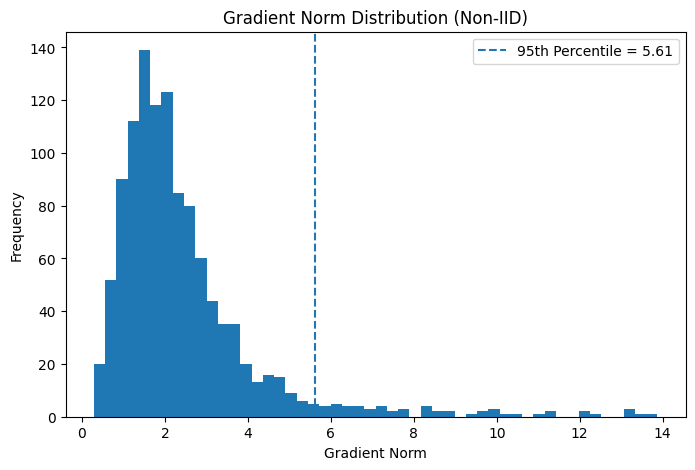

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(gradient_norms, bins=50)

plt.axvline(
    OPTIMAL_CLIP_NORM,
    linestyle='--',
    label=f'95th Percentile = {OPTIMAL_CLIP_NORM:.2f}'
)

plt.xlabel("Gradient Norm")
plt.ylabel("Frequency")
plt.title("Gradient Norm Distribution (Non-IID)")

plt.legend()
plt.show()

In [26]:
# =========================================================
# 14. RUN EXPERIMENTS
# =========================================================

# ---------------------------------------------------------
# 1. FEDAVG (NO CLIPPING)
# ---------------------------------------------------------

fedavg_acc, fedavg_loss = federated_train(
    method_name="FedAvg_NoClipping",
    clip_grad=False,
    fedprox=False,
    trimmed_mean=False,
    rounds=ROUNDS,
  clients_per_round=CLIENTS_PER_ROUND,
  local_epochs=LOCAL_EPOCHS,
     max_norm=OPTIMAL_CLIP_NORM
)



METHOD: FedAvg_NoClipping

Round 1/20

Selected Clients: [4 6 9 3 0]

Client 4 Loss: 1.6010
Client 6 Loss: 1.6347
Client 9 Loss: 1.2486
Client 3 Loss: 1.2505
Client 0 Loss: 1.1322

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.3734
Global Accuracy     : 12.12%
Accuracy Change     : +12.12%
Best Accuracy       : 12.12%
Round Duration      : 10.65 sec

Round 2/20

Selected Clients: [6 4 3 9 0]

Client 6 Loss: 1.4305
Client 4 Loss: 1.2196
Client 3 Loss: 1.0772
Client 9 Loss: 0.9663
Client 0 Loss: 0.9240

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.1235
Global Accuracy     : 23.96%
Accuracy Change     : +11.84%
Best Accuracy       : 23.96%
Round Duration      : 10.87 sec

Round 3/20

Selected Clients: [0 3 5 9 4]

Client 0 Loss: 0.7927
Client 3 Loss: 1.0159
Client 5 Loss: 0.4606
Client 9 Loss: 0.8562
Client 4 Loss: 1.0793

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 0.8409
Global Acc

In [27]:
# ---------------------------------------------------------
# 2. FEDAVG + CLIPPING
# ---------------------------------------------------------

fedavg_clip_acc, fedavg_clip_loss = federated_train(
    method_name="FedAvg_Clipping",
    clip_grad=True,
    fedprox=False,
    rounds=ROUNDS,
    clients_per_round=CLIENTS_PER_ROUND,
    local_epochs=LOCAL_EPOCHS,
    trimmed_mean=False,
    max_norm=OPTIMAL_CLIP_NORM
)



METHOD: FedAvg_Clipping

Round 1/20

Selected Clients: [8 2 9 4 5]

Client 8 Loss: 1.5991
Client 2 Loss: 1.2888
Client 9 Loss: 1.2368
Client 4 Loss: 1.5159
Client 5 Loss: 0.5112

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.2304
Global Accuracy     : 10.51%
Accuracy Change     : +10.51%
Best Accuracy       : 10.51%
Round Duration      : 10.34 sec

Round 2/20

Selected Clients: [2 4 7 0 9]

Client 2 Loss: 1.2133
Client 4 Loss: 1.2618
Client 7 Loss: 1.3873
Client 0 Loss: 1.1341
Client 9 Loss: 1.0633

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.2120
Global Accuracy     : 13.28%
Accuracy Change     : +2.77%
Best Accuracy       : 13.28%
Round Duration      : 13.00 sec

Round 3/20

Selected Clients: [5 0 8 1 3]

Client 5 Loss: 0.6480
Client 0 Loss: 0.8159
Client 8 Loss: 1.7227
Client 1 Loss: 0.6790
Client 3 Loss: 1.1093

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 0.9950
Global Accura

In [28]:
# ---------------------------------------------------------
# 3. FEDPROX + CLIPPING
# ---------------------------------------------------------

fedprox_acc, fedprox_loss = federated_train(
    method_name="FedProx_Clipping",
    clip_grad=True,
    fedprox=True,
    rounds=ROUNDS,
    clients_per_round=CLIENTS_PER_ROUND,
    local_epochs=LOCAL_EPOCHS,
    trimmed_mean=False,
    max_norm=OPTIMAL_CLIP_NORM
)



METHOD: FedProx_Clipping

Round 1/20

Selected Clients: [5 4 9 7 3]

Client 5 Loss: 0.6116
Client 4 Loss: 1.6386
Client 9 Loss: 1.2740
Client 7 Loss: 1.4264
Client 3 Loss: 1.2429

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.2387
Global Accuracy     : 13.41%
Accuracy Change     : +13.41%
Best Accuracy       : 13.41%
Round Duration      : 12.76 sec

Round 2/20

Selected Clients: [2 0 8 6 7]

Client 2 Loss: 1.2568
Client 0 Loss: 0.9700
Client 8 Loss: 1.3115
Client 6 Loss: 1.4431
Client 7 Loss: 1.2489

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.2461
Global Accuracy     : 15.13%
Accuracy Change     : +1.72%
Best Accuracy       : 15.13%
Round Duration      : 13.82 sec

Round 3/20

Selected Clients: [9 4 1 7 8]

Client 9 Loss: 0.9993
Client 4 Loss: 1.3127
Client 1 Loss: 0.7245
Client 7 Loss: 1.1428
Client 8 Loss: 1.1678

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.0694
Global Accur

In [29]:
# ---------------------------------------------------------
# 4. TRIMMED MEAN + CLIPPING
# ---------------------------------------------------------

trimmed_acc, trimmed_loss = federated_train(
    method_name="TrimmedMean_Clipping",
    clip_grad=True,
    fedprox=False,
    rounds=ROUNDS,
    clients_per_round=CLIENTS_PER_ROUND,
    local_epochs=LOCAL_EPOCHS,
    trimmed_mean=True,
     max_norm=OPTIMAL_CLIP_NORM
)


METHOD: TrimmedMean_Clipping

Round 1/20

Selected Clients: [9 4 3 7 5]

Client 9 Loss: 1.2501
Client 4 Loss: 1.5970
Client 3 Loss: 1.2249
Client 7 Loss: 1.4172
Client 5 Loss: 0.5533

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.2085
Global Accuracy     : 10.59%
Accuracy Change     : +10.59%
Best Accuracy       : 10.59%
Round Duration      : 11.62 sec

Round 2/20

Selected Clients: [8 2 0 4 5]

Client 8 Loss: 1.4161
Client 2 Loss: 1.2791
Client 0 Loss: 1.0223
Client 4 Loss: 1.2774
Client 5 Loss: 0.4522

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.0894
Global Accuracy     : 12.63%
Accuracy Change     : +2.04%
Best Accuracy       : 12.63%
Round Duration      : 9.47 sec

Round 3/20

Selected Clients: [2 4 6 9 3]

Client 2 Loss: 1.1941
Client 4 Loss: 1.3325
Client 6 Loss: 1.4859
Client 9 Loss: 1.0971
Client 3 Loss: 1.1063

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.2432
Global Ac

In [30]:
# ---------------------------------------------------------
# 5. SCAFFOLD + CLIPPING
# ---------------------------------------------------------

scaffold_acc, scaffold_loss = federated_train(
    method_name="SCAFFOLD_Clipping",
    clip_grad=True,
    fedprox=False,
    trimmed_mean=False,
    rounds=ROUNDS,
    clients_per_round=CLIENTS_PER_ROUND,
    local_epochs=LOCAL_EPOCHS,
    scaffold=True,
    max_norm=OPTIMAL_CLIP_NORM
)


METHOD: SCAFFOLD_Clipping

Round 1/20

Selected Clients: [5 2 8 7 3]

Client 5 Loss: 0.7650
Client 2 Loss: 1.3414
Client 8 Loss: 1.8821
Client 7 Loss: 1.4897
Client 3 Loss: 1.3343

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 1.3625
Global Accuracy     : 10.57%
Accuracy Change     : +10.57%
Best Accuracy       : 10.57%
Round Duration      : 12.79 sec

Round 2/20

Selected Clients: [1 2 5 0 4]

Client 1 Loss: 1.5677
Client 2 Loss: 2.9148
Client 5 Loss: 2.9562
Client 0 Loss: 1.2812
Client 4 Loss: 1.7288

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 2.0898
Global Accuracy     : 10.48%
Accuracy Change     : -0.09%
Best Accuracy       : 10.57%
Round Duration      : 10.94 sec

Round 3/20

Selected Clients: [3 1 7 0 8]

Client 3 Loss: 2.5480
Client 1 Loss: 2.3156
Client 7 Loss: 2.5879
Client 0 Loss: 2.4093
Client 8 Loss: 2.4875

-------------------- ROUND SUMMARY --------------------

Average Client Loss : 2.4697
Global Accu

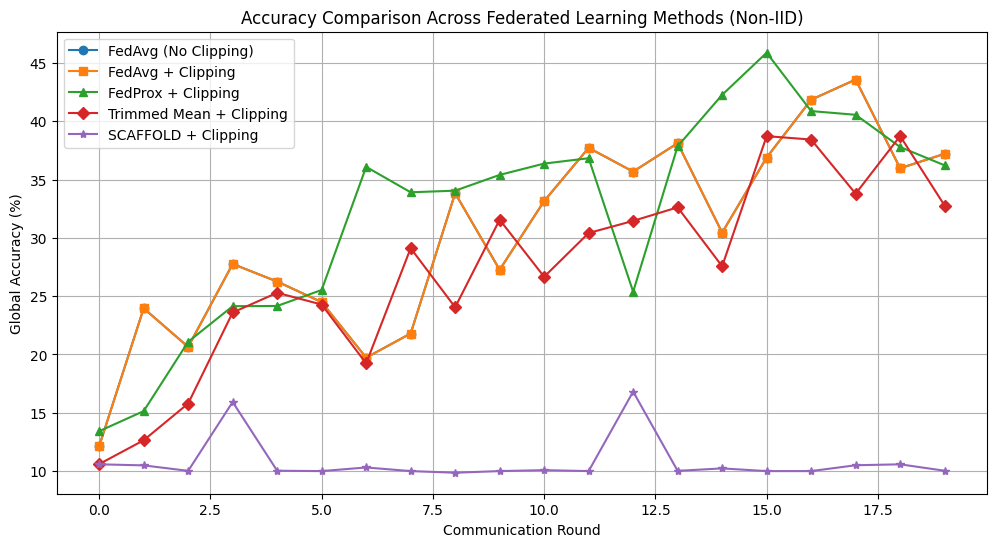

In [31]:
# =========================================================
# ACCURACY COMPARISON
# =========================================================

plt.figure(figsize=(12, 6))

plt.plot(
    fedavg_acc,
    marker='o',
    label="FedAvg (No Clipping)"
)

plt.plot(
    fedavg_acc,
    marker='s',
    label="FedAvg + Clipping"
)

plt.plot(
    fedprox_acc,
    marker='^',
    label="FedProx + Clipping"
)

plt.plot(
    trimmed_acc,
    marker='D',
    label="Trimmed Mean + Clipping"
)

plt.plot(
    scaffold_acc,
    marker='*',
    label="SCAFFOLD + Clipping"
)

plt.xlabel("Communication Round")
plt.ylabel("Global Accuracy (%)")
plt.title("Accuracy Comparison Across Federated Learning Methods (Non-IID)")

plt.legend()
plt.grid(True)

plt.show()

In [32]:
# =========================================================
# 16. SAVE PLOT
# =========================================================

plot_path = os.path.join(
    project_path,
    "fl_comparison_plot.png"
)

plt.savefig(plot_path)

print("\nPlot Saved To:")
print(plot_path)


Plot Saved To:
/content/drive/MyDrive/FL_Project/fl_comparison_plot.png


<Figure size 640x480 with 0 Axes>